In [1]:
import numpy as np
import matplotlib.pyplot as plt

import substrate_depletion_model as sd
import dimensionless as dim
import utils as u

## Predictions on 72 hr Neuruloids data
This notebook aims to summarise the findings and predictions that can be made from a 2-component models on the pattern formation of neuruloids system. Current data from images at 72 hours by eye:
- 200 microns - 6 images with 1 peak 
- 250 microns - 3 images with 2 peak, 1 image with 1 peak 
- 350 microns - 3 images with 2 peaks 
- 500 microns - 3 images with 3 peaks

<!-- \begin{enumerate}
    \item 200 microns - 1 peak 
    \item 250 microns - 3 images with 2 peak, 1 image with 1 peak 
    \item 350 microns - 3 images with 2 peaks 
    \item 500 microns - 3 images with 3 peaks
\end{enumerate} -->

### 1. Mass-conserved substrate-depletion model
Predictions from random perturbations from uniform concentration as initial condtions, solving the deterministic PDE:

$$
\frac{\partial S}{\partial t} = D_s \frac{\partial^2 S}{\partial x^2} + k_{on}Pf(S) - k_{off}S
$$

$$
\frac{\partial P}{\partial t} = D_p \frac{\partial^2 P}{\partial x^2} - k_{on}Pf(S) + k_{off}S
$$

where Hill function

$$
f(S) = \frac{S^n}{S_0^n + S^n}
$$

and total amount of $S$ and $P$,and total concentration is conserved at all times, $t$:

$$
N = \int P(x,t) + S(x,t) dx
$$

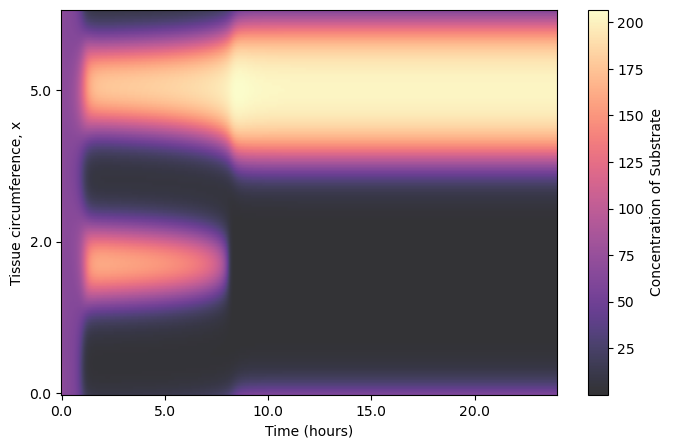

In [2]:
# plot predictions of distribution at 72 hours for lenghts (200-600 microns)

# dimensionless parameters
Ds_Dp = 0.05
kon_koff = 20
S0_conc = 2

# fixed parameters
k_off = 12.5 
Ds = 0.055*(np.pi)**2

# neuruloid diameter (need to multiple Ds pi^2 to get same results in circumference)
Diameters = np.linspace(2, 7, 11) # fix 1 unit is 100 microns
Radii = Diameters/2
Lengths = Diameters*np.pi
sqrt_D0_Ds = Lengths*np.sqrt(k_off/Ds) # dimensionless lengths

# corresponding params
Dp = Ds/Ds_Dp
k_on = k_off*kon_koff
conc = 100
S0 = conc*S0_conc

# INSERT NEURULOID DIAMETER TO MAKE PREDICTIONS!!
Diameter = 2 # INSERT DIAMETER IN 10^2 MICRONS
L = Diameter*np.pi # CIRCUMFERENCE IN 10^2 MICRONS
dx = 0.05
x = np.arange(0, L+dx, dx)
N_total = int(conc*L)

# initial conditions (random perturbations)
Si = u.random_perturbations(x, N_total, noise=0.1*conc)
Pi = np.zeros(len(x)) 

# solve the pde given random initial conditions
T_final = 24
dt = 0.01
S, P = sd.imex_SD(Si,
                  Pi,
                  N_total,
                  dt=dt,
                  dx=dx,
                  t_steps=int(T_final/dt),
                  D_s=Ds,
                  D_p=Dp,
                  kon=k_on,
                  koff=k_off,
                  n=2,
                  S0=S0)

# AS HEATMAP PLOTS
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(S, origin="lower", aspect='auto', cmap="magma", alpha=0.8)
xtick = np.arange(0, S.shape[1], 500)
ytick = np.arange(0, S.shape[0], 50)
ax.set(xticks=xtick, xticklabels=xtick*(T_final/(S.shape[1]-1)))
ax.set(yticks=ytick, yticklabels=np.round(ytick*(L/(S.shape[0]-1))))
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Tissue circumference, x")
plt.colorbar(im, shrink=1, label="Concentration of Substrate")

In [3]:
# from tqdm import tqdm
# # plot heatmaps for some length
# # Code to compare different lengths
# T_final = 24
# Diameters = np.array([2.5, 3.5, 5]) # fix 1 unit is 100 microns
# # Radii = Diameters/2
# Ls = Diameters*np.pi
# AL = []

# for i in tqdm(range(len(Ls))):
#     L = Ls[i]
    
#     dx = 0.1
#     x = np.arange(0, L+dx, dx)
#     N_total = int(conc*L)
    
#     # initial conditions
#     # initial conditions (random perturbations)
#     Si = u.random_perturbations(x, N_total, noise=0.01)
#     Pi = np.zeros(len(x)) 
    
#     S, P = sd.imex_SD(Si,
#                       Pi,
#                       N_total,
#                       dt=dt,
#                       dx=dx,
#                       t_steps=int(T_final/dt),
#                       D_s=Ds,
#                       D_p=Dp,
#                       kon=k_on,
#                       koff=k_off,
#                       n=2,
#                       S0=S0)
    
#     AL.append(S)

In [4]:
# # plot heat map for different lengths
# fig, ax = plt.subplots(len(Ls), 1, figsize=(7, 10))
# vmin = min(AL[-1][:,-1])
# vmax = max(AL[-1][:,-1])

# for i in range(len(Ls)):
#     At = AL[i]
#     L = Ls[i]
    
#     im = ax[i].imshow(At, origin="lower", aspect='auto', vmin=vmin, vmax=vmax, cmap="magma", alpha=0.8)
    
#     xtick = np.arange(0, At.shape[1], 500)
#     ytick = np.arange(0, At.shape[0], 25)
    
#     ax[i].set(xticks=xtick, xticklabels=xtick*(T_final/(At.shape[1]-1)))
#     ax[i].set(yticks=ytick, yticklabels=np.round(ytick*(L/(At.shape[0]-1)), 1))
#     ax[i].set_ylabel(f"D={int(Diameters[i]*100)} $\mu$m", fontsize=10, rotation=90)
    
# # plt.colorbar(im, shrink=1, label="Concentration of Substrate")
    
# ax[-1].set_xlabel("Time (hours)", fontsize=14)

# fig.colorbar(im, 
#              ax=[ax[i] for i in range(len(Ls))],
#              orientation="horizontal",
#              label="Concentration of Substrate Molecules",
#              shrink=1, 
#              pad=0.08)

# fig.text(0.005, 0.40, r"Tissue Circumference, $x$ ($10^2$ $\mu$m)", ha="center", rotation="vertical", fontsize=14)

In [5]:
# For stochastic reactions
from tqdm import tqdm
T_final = 24
Diameter = 5 # fix 1 unit is 100 microns
# Radii = Diameters/2
L = Diameter*np.pi

# random initial conditions
dx = 0.1
x = np.arange(0, L+dx, dx)
N_total = int(conc*L)
Si = u.random_perturbations(x, N_total, noise=0.01)
Pi = np.zeros(len(x)) 

AL = []
A = [100, 50, 10]

for i in tqdm(range(len(A))):
    S, P = sd.substrate_depletion_IMTL(Si,
                                       Pi,
                                       N_total,
                                       Tf=T_final,
                                       A=A[i],
                                       dt=dt,
                                       dx=dx,
                                       D_s=Ds,
                                       D_p=Dp,
                                       kon=k_on,
                                       koff=k_off,
                                       n=2,
                                       S0=S0)
    
    
    AL.append(S)

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:04<00:00,  1.62s/it]


Text(0.005, 0.3, 'Tissue Circumference, $x$ ($10^2$ $\\mu$m)')

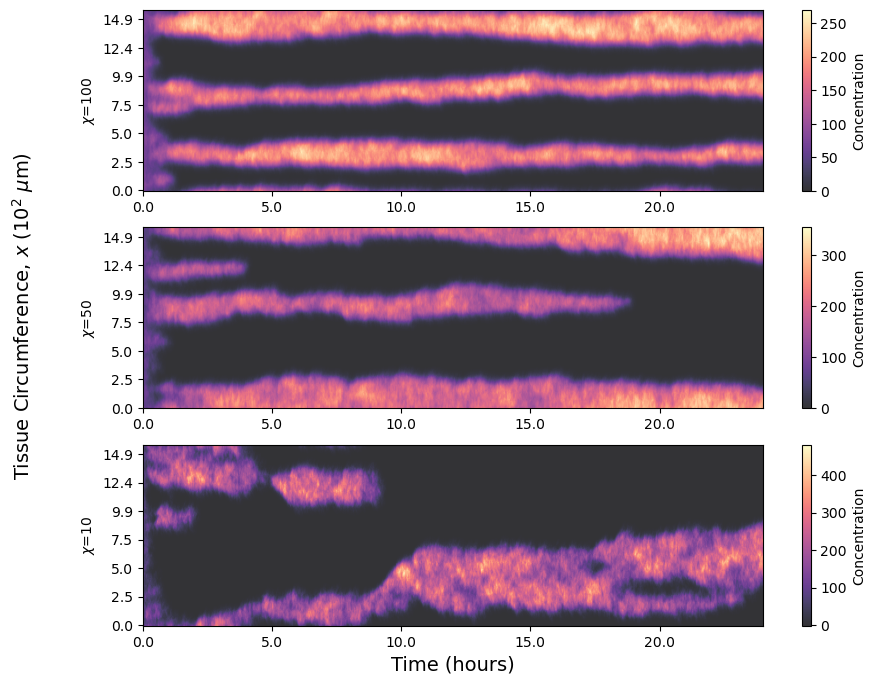

In [15]:
# plot heat map for different noise levels
fig, ax = plt.subplots(len(A), 1, figsize=(10, 8))
vmin = min(AL[-1][:,-1])
vmax = max(AL[-1][:,-1])

for i in range(len(A)):
    At = AL[i]
    
    im = ax[i].imshow(At, origin="lower", aspect='auto', cmap="magma", alpha=0.8)
    
    fig.colorbar(im, 
                 ax=ax[i],
                 orientation="vertical",
                 label="Concentration",
                 shrink=1)
    
    xtick = np.arange(0, At.shape[1], 500)
    ytick = np.arange(0, At.shape[0], 25)
    
    ax[i].set(xticks=xtick, xticklabels=xtick*(T_final/(At.shape[1]-1)))
    ax[i].set(yticks=ytick, yticklabels=np.round(ytick*(L/(At.shape[0]-1)), 1))
    ax[i].set_ylabel(f"$\chi$={A[i]}", fontsize=10, rotation=90)

    
ax[-1].set_xlabel("Time (hours)", fontsize=14)

fig.text(0.005, 0.30, r"Tissue Circumference, $x$ ($10^2$ $\mu$m)", ha="center", rotation="vertical", fontsize=14)

[2.20450359]


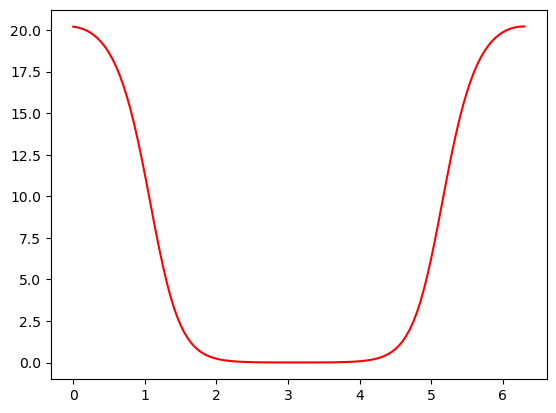

In [7]:
from scipy.signal import argrelextrema
from scipy.signal import peak_widths, find_peaks

Sf = S[:,-1]
peak_idx = argrelextrema(Sf, np.greater, mode='wrap')[0]
peak_loc = peak_idx*L/len(x)
# print(peak_idx)
# print(peak_loc)

# def fwhm(space_data, peak_idx, L, dx, mode="periodic"):
#     """
#     Returns full-width half maximum scaled with domain length, L
#     """
#     nx = len(space_data)
    
#     if mode=="periodic":
#         pad_length = 0.5*L
#         n_pad = int(pad_length/dx)
#         padded_data = np.concatenate((space_data[-n_pad:], space_data, space_data[:n_pad]))
#         padded_peak_idx = peak_idx + n_pad
#         widths = peak_widths(padded_data, padded_peak_idx, rel_height=0.5)[0]
        
#     elif mode=="hard":
#         widths = peak_widths(space_data, peak_idx, rel_height=0.5)[0]
        
#     fwhm = widths*L/nx
#     return padded_data, padded_peak_idx, fwhm #fwhm
        

plt.plot(x, Sf, color="red")
width = u.fwhm(Sf, peak_idx, L, dx, mode="periodic")
print(width)


In [28]:
# plotting modes vs length for default set of parameters!!!
Diameters = np.linspace(2, 7, 11) # fix 1 unit is 100 microns
Radii = Diameters/2
Lengths = Diameters*np.pi

FOLDER = "neuruloid_predictions"
with open(f"{FOLDER}/peak_number_24hr_b.npy", "rb") as file:
    peaks_num = np.load(file, allow_pickle=True)
    
with open(f"{FOLDER}/angle_separation_24hr_b.npy", "rb") as file:
    angle_separation = np.load(file, allow_pickle=True)

with open(f"{FOLDER}/peak_fwhm_24hr_b.npy", "rb") as file:
    fwhm = np.load(file, allow_pickle=True)

peak_data = [peaks_num[i, :] for i in range(len(Lengths))]

Text(0.5, 0.93, 'Mass-Conserved Substrate-Depletion model')

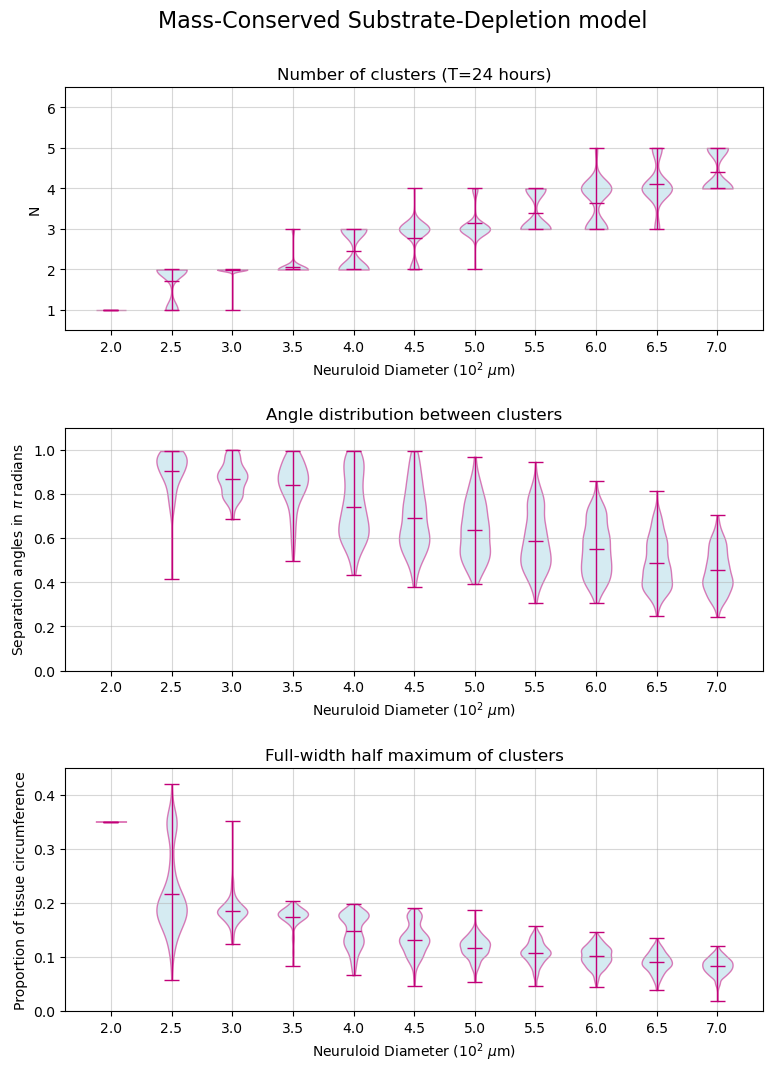

In [34]:
# plot the figure (from 50 samples of random ic)
fig, ax = plt.subplots(3, 1, figsize=(9, 12))
plt.subplots_adjust(hspace=0.4)

ax[0].set_title("Number of clusters (T=24 hours)", fontsize=12)
ax[0].set_ylim(0.5, 6.5)
ax[0].set_ylabel("N", fontsize=10)
ax[0].set_xlabel(r"Neuruloid Diameter ($10^2$ $\mu$m)", fontsize=10)
ax[0].grid(alpha=0.5)
vp1 = ax[0].violinplot(peak_data, showmeans=True)

ax[1].set_title("Angle distribution between clusters", fontsize=12)
ax[1].set_ylim(0, 1.1)
ax[1].set_ylabel(r"Separation angles in $\pi$ radians", fontsize=10)
ax[1].set_xlabel(r"Neuruloid Diameter ($10^2$ $\mu$m)", fontsize=10)
ax[1].grid(alpha=0.5)
nans = [float('nan'), float('nan')] 
vp2 = ax[1].violinplot([val or nans for val in angle_separation], showmeans=True)

ax[2].set_title("Full-width half maximum of clusters", fontsize=12)
ax[2].set_ylim(0, 0.45)
ax[2].set_ylabel(r"Proportion of tissue circumference", fontsize=10)
ax[2].set_xlabel(r"Neuruloid Diameter ($10^2$ $\mu$m)", fontsize=10)
ax[2].grid(alpha=0.5)
vp3 = ax[2].violinplot([fwhm[i]/Lengths[i] for i in range(len(fwhm))], showmeans=True)


for vp in [vp1, vp2, vp3]:
    for partname in ('cbars','cmins','cmaxes','cmeans'):
        pc = vp[partname]
        pc.set_edgecolor('#C20078')
        pc.set_linewidth(1)
    for pc in vp['bodies']:
        pc.set_facecolor('#ADD8E6')
        pc.set_edgecolor('#C20078')
        pc.set_alpha(0.5)

def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels)+1, 1), labels=labels)
    ax.set_xlim(0.25, len(labels)+0.75)
    
for i in ax:
    set_axis_style(i, Diameters)

# fig.tight_layout()
fig.text(0.5, 0.93, "Mass-Conserved Substrate-Depletion model", ha="center", rotation="horizontal", fontsize=16)
# fig.text(0.5, 1.0, "Neuruloid Predictions", ha="center", rotation="horizontal", fontsize=16)
# fig.text(0.5, 0.95, "(from deterministic mass-conserved substrate-depletion model)", ha="center", rotation="horizontal", fontsize=11, weight="bold")